DATASET INFORMATION
Shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3      

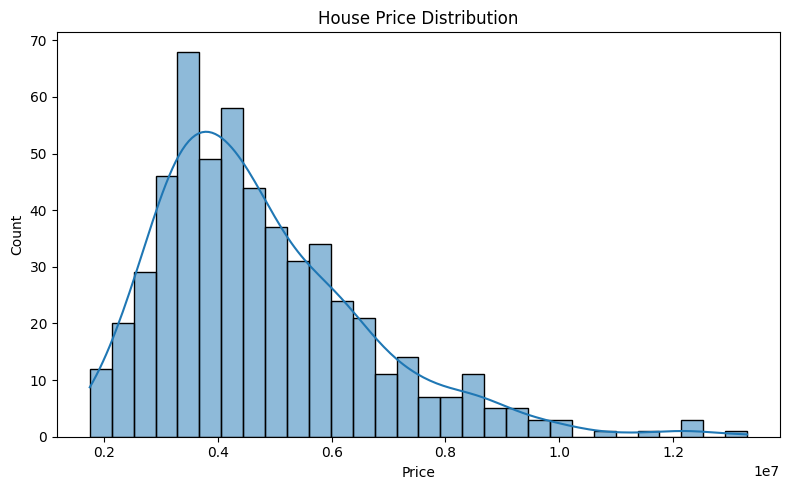

Saved: images/price_distribution.png


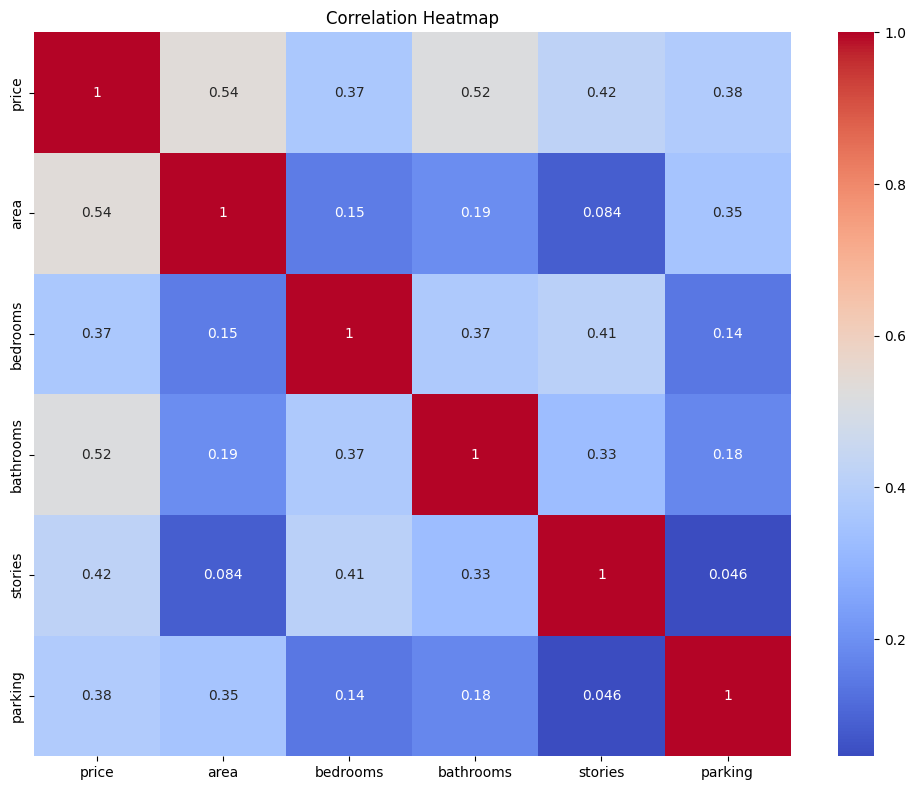

Saved: images/correlation_heatmap.png

Correlation with Price
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


MODEL COMPARISON
               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.013969e+06  1.398116e+06  0.613275
2            XGBoost  9.864931e+05  1.327610e+06  0.651296


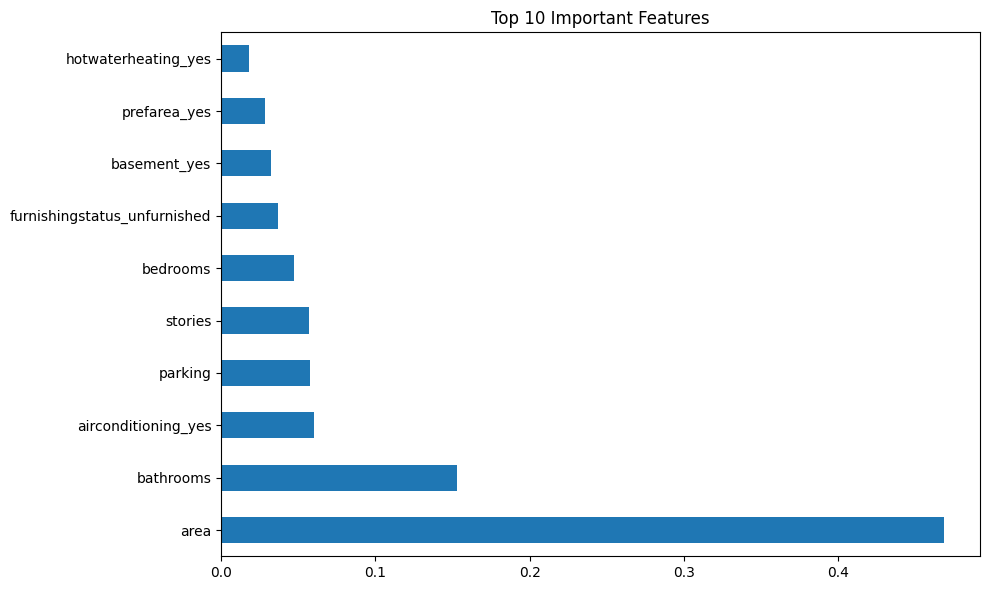

Saved: images/feature_importance.png


SAMPLE PREDICTION
Predicted Price: 4592833.0
Actual Price: 4060000

results.md generated successfully!


In [3]:
# ==========================================
# HOUSE PRICE PREDICTION PROJECT
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("../data/kaggle-housing.csv")

print("="*50)
print("DATASET INFORMATION")
print("="*50)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# PRICE DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../images/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: images/price_distribution.png")

# ==========================================
# CORRELATION HEATMAP
# ==========================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: images/correlation_heatmap.png")

# ==========================================
# CORRELATION WITH PRICE
# ==========================================

print("\nCorrelation with Price")

corr_values = (
    numeric_df.corr()["price"]
    .sort_values(ascending=False)
)

print(corr_values)

# ==========================================
# ENCODE CATEGORICAL VARIABLES
# ==========================================

df = pd.get_dummies(
    df,
    drop_first=True
)

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop("price", axis=1)

y = df["price"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# LINEAR REGRESSION
# ==========================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

# ==========================================
# XGBOOST
# ==========================================

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

print("\n")
print("="*50)
print("MODEL COMPARISON")
print("="*50)

print(results)

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top10 = importance.nlargest(10)

plt.figure(figsize=(10,6))

top10.plot(
    kind="barh"
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: images/feature_importance.png")

# ==========================================
# SAMPLE PREDICTION
# ==========================================

sample_house = X_test.iloc[[0]]

prediction = xgb.predict(
    sample_house
)

print("\n")
print("="*50)
print("SAMPLE PREDICTION")
print("="*50)

print(
    "Predicted Price:",
    round(prediction[0], 2)
)

print(
    "Actual Price:",
    y_test.iloc[0]
)

# ==========================================
# SAVE RESULTS
# ==========================================

with open("../results.md", "w") as f:

    f.write("# House Price Prediction Results\n\n")

    f.write("## Linear Regression\n")
    f.write(f"MAE: {lr_mae:.2f}\n")
    f.write(f"RMSE: {lr_rmse:.2f}\n")
    f.write(f"R2 Score: {lr_r2:.4f}\n\n")

    f.write("## Random Forest\n")
    f.write(f"MAE: {rf_mae:.2f}\n")
    f.write(f"RMSE: {rf_rmse:.2f}\n")
    f.write(f"R2 Score: {rf_r2:.4f}\n\n")

    f.write("## XGBoost\n")
    f.write(f"MAE: {xgb_mae:.2f}\n")
    f.write(f"RMSE: {xgb_rmse:.2f}\n")
    f.write(f"R2 Score: {xgb_r2:.4f}\n\n")

print("\nresults.md generated successfully!")